<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Spatial_relarionships.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

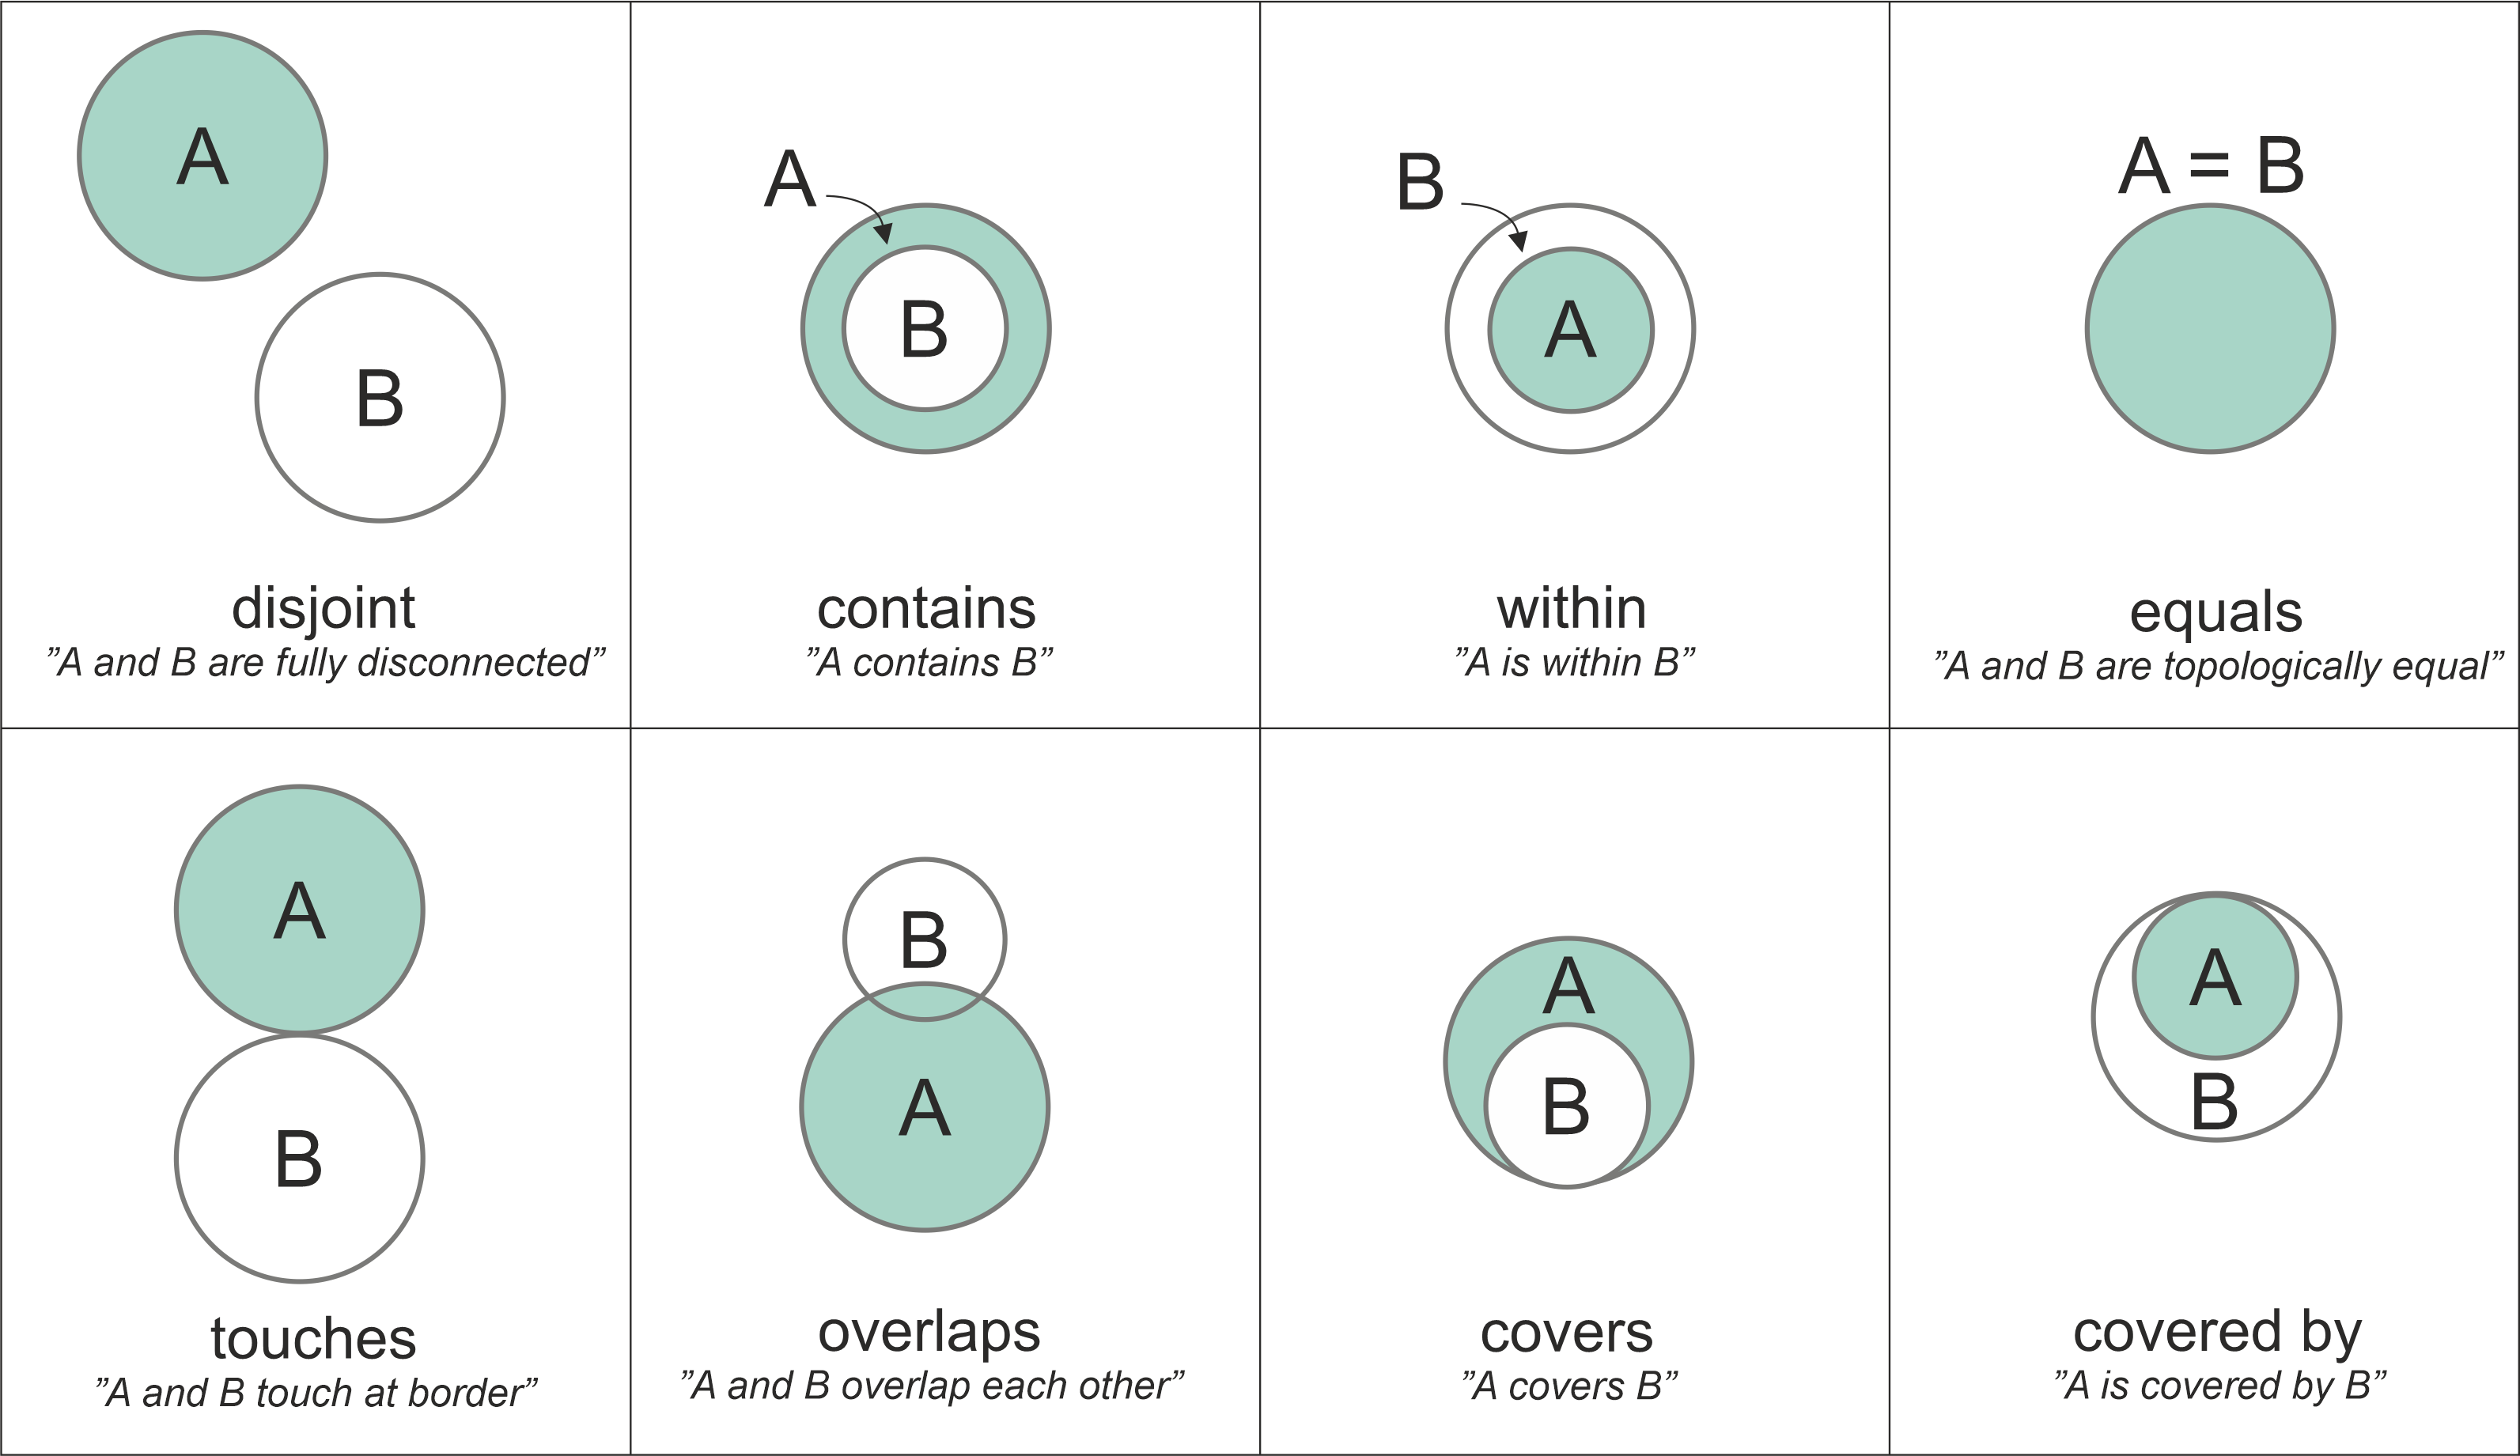

In [1]:
from shapely import Point, Polygon

# Create Point objects
point1 = Point(24.952242, 60.1696017)
point2 = Point(24.976567, 60.1612500)

# Create a Polygon
coordinates = [
    (24.950899, 60.169158),
    (24.953492, 60.169158),
    (24.953510, 60.170104),
    (24.950958, 60.169990),
]
polygon = Polygon(coordinates)

In [2]:
point1.within(polygon)

True

In [3]:
point2.within(polygon)

False

.intersects() - Two objects intersect if the boundary or interior of one object intersect in any way with the boundary or interior of the other object.

.touches() - Two objects touch if the objects have at least one point in common and their interiors do not intersect with any part of the other object.

In [4]:
from shapely import LineString, MultiLineString

# Create two lines
line_a = LineString([(0, 0), (1, 1)])
line_b = LineString([(1, 1), (0, 2)])

In [5]:
line_a.intersects(line_b)

True

In [6]:
line_a.touches(line_b)

True

In [7]:
print("Intersects?", point1.intersects(polygon))
print("Within?", point1.within(polygon))
print("Contains?", point1.contains(polygon))
print("Overlaps?", point1.overlaps(polygon))
print("Touches?", point1.touches(polygon))
print("Covers?", point1.covers(polygon))
print("Covered by?", point1.covered_by(polygon))
print("Equals?", point1.equals(polygon))
print("Disjoint?", point1.disjoint(polygon))
print("Crosses?", point1.crosses(polygon))

Intersects? True
Within? True
Contains? False
Overlaps? False
Touches? False
Covers? False
Covered by? True
Equals? False
Disjoint? False
Crosses? False


## Spatial queries using geopandas

In [8]:
import geopandas as gpd

In [9]:
import requests, os

In [10]:
data_folder = "data"
output_folder = 'output'

if not os.path.exists(data_folder):
    os.makedirs(data_folder)

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [11]:
def download (url):
  filename = os.path.join(data_folder, os.path.basename(url))

  if not os.path.exists(filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
      f.write(response.content)
  print('downloaded: ', filename)

In [12]:
url_path = 'https://raw.githubusercontent.com/daveveed/Geo-Data-Science/main/Data/Temp/addresses.gpkg'

download(url_path)

downloaded:  data/addresses.gpkg


In [13]:
url_path_2 = 'https://raw.githubusercontent.com/daveveed/Geo-Data-Science/main/Data/Temp/helsinki_city_districts_2021.gpkg'
download(url_path_2)

downloaded:  data/helsinki_city_districts_2021.gpkg


In [14]:
input_data_path = os.path.join(data_folder, 'addresses.gpkg')

points = gpd.read_file(input_data_path)
districts = gpd.read_file(os.path.join(data_folder, 'helsinki_city_districts_2021.gpkg'))

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'addresses.gpkg': 'addresses' (default), 'addresses_with_population_data'. Specify layer parameter to avoid this warning.
  result = read_func(


In [16]:
points.shape

(34, 2)

In [17]:
districts.shape

(8, 2)

In [18]:
points.head()

,address,geometry
0,"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns...",POINT (24.91556 60.1632)
1,"1, Kampinkuja, Kamppi, Eteläinen suurpiiri, He...",POINT (24.93009 60.16846)
2,"Espresso House, 8, Kaivokatu, Keskusta, Kluuvi...",POINT (24.94153 60.17016)
3,"Hermannin rantatie, Verkkosaari, Kalasatama, S...",POINT (24.97853 60.1905)
4,"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",POINT (24.92169 60.15667)


In [19]:
districts.tail()

,name,geometry
3,Pohjoinen,"POLYGON ((24.90081 60.23526, 24.89944 60.235, ..."
4,Koillinen,"POLYGON ((24.97163 60.24253, 24.97163 60.24246..."
5,Kaakkoinen,"POLYGON ((24.84809 60.02756, 24.85113 60.02417..."
6,Itäinen,"POLYGON ((25.03602 60.2357, 25.03628 60.23577,..."
7,Östersundom,"POLYGON ((25.1397 60.24153, 25.13899 60.24091,..."


 we are interested in finding all points that are within two areas in Helsinki region, namely Itäinen and Eteläinen (‘Eastern’ and ‘Southern’ in English)

In [20]:
selection = districts.loc[districts['name'].isin(['Itäinen', 'Eteläinen'])]
selection

,name,geometry
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,..."
6,Itäinen,"POLYGON ((25.03602 60.2357, 25.03628 60.23577,..."


<Axes: >

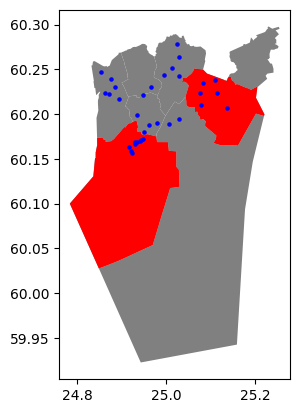

In [21]:
base = districts.plot(facecolor='gray')
selection.plot(ax=base, facecolor='red')
points.plot(ax=base, color='blue', markersize=5)

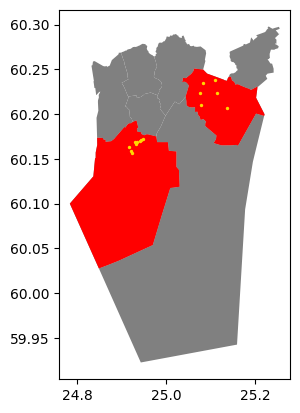

In [22]:
selected_points = points.sjoin(selection.geometry.to_frame(), predicate="within")

ax = districts.plot(facecolor="gray")
ax = selection.plot(ax=ax, facecolor="red")
ax = selected_points.plot(ax=ax, color="gold", markersize=2)

Notice how we used the selection.geometry.to_frame() when calling the .sjoin() method. This is a special trick to avoid attaching any extra attributes from the selection geodataframe to our data, which is what .sjoin() method would normally do (and which it is actually designed for). As we are only interested in the geometries of the right-hand-side layer to do the selection, calling the .geometry.to_frame() will first select the geometry column from the selection layer and then converts it into a GeoDataFrame (which would otherwise be a GeoSeries). An alternative approach for doing the same thing is to use selection[[selection.active_geometry_name]], which also returns a GeoDataFrame containing only a column with the geodataframe’s active geometry.

In a similar manner, we can easily use the .sjoin() with other predicates to make selections based on how the geometries between two GeoDataFrames are related to each other. By default, the .sjoin() uses "intersects" as a spatial predicate, but it is easy to change this. For example, we can investigate which of the districts contain at least one point. In this case, we make a spatial join using the disctricts GeoDataFrame as a starting point, join the layer with the points and use the "contains" as a value to our predicate parameter:

In [23]:
districts_with_points = districts.sjoin(
    points.geometry.to_frame(), predicate="contains"
)

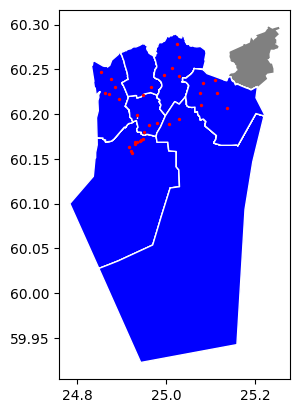

In [25]:
ax = districts.plot(facecolor="gray")
ax = districts_with_points.plot(ax=ax, facecolor='blue', edgecolor='white')
ax = points.plot(ax=ax, color="red", markersize=2)

 One important thing to remember whenever making spatial queries is that both layers need to share the same Coordinate Reference System for the selection to work properly. A typical reason for getting incorrect results when selecting data (likely an empty GeoDataFrame) is that one data layer is e.g. in WGS84 coordinate reference system whereas the other one is in some projected CRS, such as ETRS-LAEA. If this happens, you can easily fix the situation by defining and reprojecting both GeoDataFrames to same CRS using the .to_crs() method

In [26]:
districts.sindex.valid_query_predicates

{None,
 'contains',
 'contains_properly',
 'covered_by',
 'covers',
 'crosses',
 'dwithin',
 'intersects',
 'overlaps',
 'touches',
 'within'}

How many addresses are located in each district? You can find out the answer by grouping the spatial join result based the district name (see Part I, chapter 3 for a reminder on how to group and aggregate data).

In [27]:
districts_with_points.head()

,name,geometry,index_right
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,...",4
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,...",32
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,...",0
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,...",31
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,...",1


In [29]:
grouped = districts_with_points.groupby('name')

In [32]:
grouped.index_right.count()

,index_right
name,
Eteläinen,9
Itäinen,6
Kaakkoinen,2
Keskinen,4
Koillinen,5
Läntinen,6
Pohjoinen,2
